# Lab 2 - Atlas & Statistical shape analysis
This lab is designed to help you construct an atlas. The code and this lab will rely on multimorph.

Be sure to select the GPU in Colab for training (Runtime > Change runtime type > T4 GPU (or any other GPU available).

References:

*  Abulnaga et al., MultiMorph: On-demand Atlas Construction, CPVR 2025 : https://arxiv.org/abs/2504.00247
*   https://github.com/mabulnaga/multimorph



### Evaluation

Documents to submit :
* This notebook with your code and comments (8 points).
* A report (pdf format) presenting what you did, the statistical shape analysis you did, etc. (12 points). Maximum 3 pages.

Only one student per group needs to submit.

**Deadline** : March 10, 2026

# Atlas

### Model used

We'll be using multimorph to create an atlas.

In [1]:
# !git clone https://github.com/mabulnaga/multimorph.git
# %cd multimorph/src

### Load Libraries

In [1]:
!pip install neurite
!pip install monai --no-deps
#!pip install git+https://github.com/adalca/neurite.git --force-reinstall --no-deps
#!pip install pystrum

In [2]:
import pathlib
import os

import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from tqdm.notebook import trange, tqdm

os.environ['NEURITE_BACKEND'] = 'pytorch'
os.environ['VXM_BACKEND'] = 'pytorch'
import neurite as ne

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
%cd multimorph/src

/store/usagers/mumara/shape_analysis/GBM6953HE_labs/lab2/multimorph/src


## Dataset
The dataset is, once again, Neurite OASIS (MRI brain scans).

In [4]:
!mkdir -p oasisdata
!wget -q https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data/neurite-oasis.2d.v1.0.tar
!tar xf neurite-oasis.2d.v1.0.tar -C oasisdata/
!rm neurite-oasis.2d.v1.0.tar

### Load the Dataset

In [5]:
oasis_data_path ='oasisdata'

files = [f/'slice_norm.nii.gz' for f in pathlib.Path(oasis_data_path).iterdir() if f.is_dir()]
slices = [torch.from_numpy(nib.load(f).get_fdata())[..., 0] for f in files]
oasis_data = torch.stack(slices, dim=0).float().to(device) # put all data on cuda.

# get the segmentations
seg_files = [f/'slice_seg4.nii.gz' for f in pathlib.Path(oasis_data_path).iterdir() if f.is_dir()]
seg_slices = [torch.from_numpy(nib.load(f).get_fdata())[...,0] for f in seg_files]
oasis_data_segmentation = torch.stack(seg_slices,dim=0).float().to(device)


oasis_data = oasis_data.transpose(2, 1)
oasis_data_segmentation = oasis_data_segmentation.transpose(2,1).unsqueeze(1)


### Prepare the data


In [6]:
from dataloader import GroupDataLoader, SubGroupLoader

# import importlib.util

# spec = importlib.util.spec_from_file_location(
#     "dataloader", "/usagers3/mumara/miniconda3/envs/shape_analysis/lib/python3.13/site-packages/dataloader/dataloader.py"
# )

# mod = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(mod)
# read_data_sets = mod.read_data_sets
# GroupDataLoader = mod.GroupDataLoader
# SubGroupLoader = mod.SubGroupLoader


from torch.utils.data import DataLoader

# number of images to sample at each training iteration
n_inputs_range = [2,12]


train_pct = 0.9
N_data = len(oasis_data)
N_train = int(N_data * train_pct)
N_test = N_data - N_train
range_data = np.arange(0,N_data)
train_idx = np.random.choice(range_data, N_train, replace=False)
test_idx =np.setdiff1d(range_data, train_idx)

# split the image and segmentations into the appropriate data split
oasis_data_train = oasis_data[train_idx,:]
oasis_data_test = oasis_data[test_idx,:]
oasis_data_segmentation_train = oasis_data_segmentation[train_idx,:]
oasis_data_segmentation_test = oasis_data_segmentation[test_idx,:]

# create data loaders for train and test. The GroupDataLoader will randomly sample n_input_ranges image at each iteration.
# for the test data loader, we load the entire test set.

dataset_oasis_train = GroupDataLoader(data=oasis_data_train,labels=np.zeros(N_train), class_labels=[0],
                                      segmentations=oasis_data_segmentation_train, n_inputs_range=n_inputs_range,transform=None)
dataloader_oasis_train = DataLoader(dataset_oasis_train,batch_size=1,shuffle=True)

dataset_oasis_test = SubGroupLoader(data=[oasis_data_test],labels=None, # labels=[np.zeros(N_test)],
                                     segmentations=[oasis_data_segmentation_test], transform=None)
dataloader_oasis_test = DataLoader(dataset_oasis_test, batch_size=1, shuffle=False)



#### Visualize a few samples from the dataloader

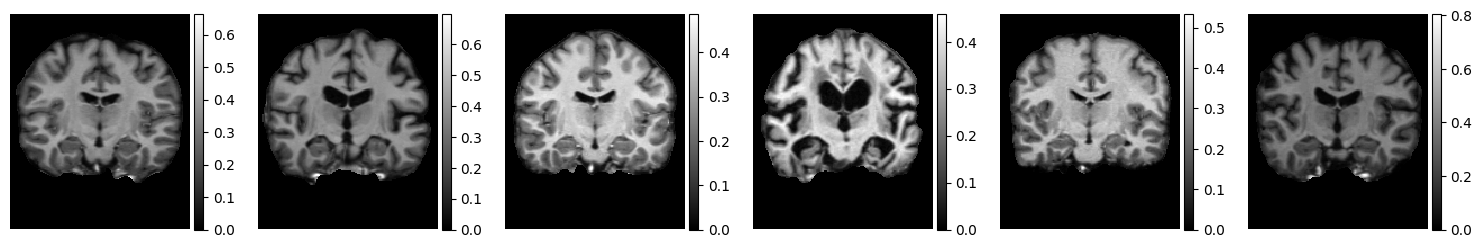

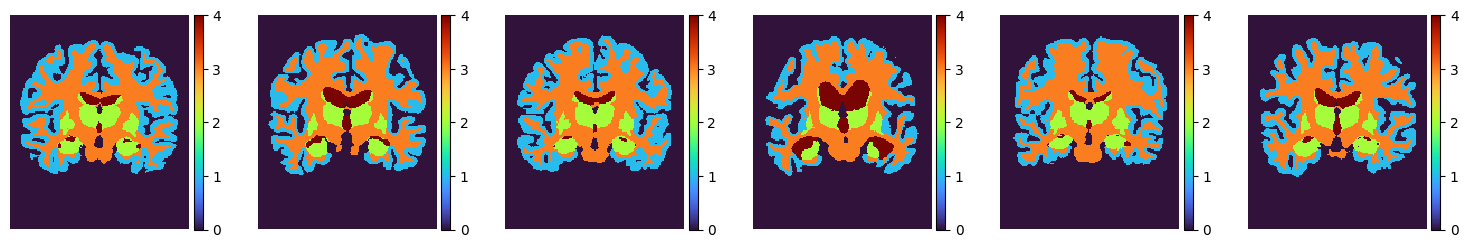

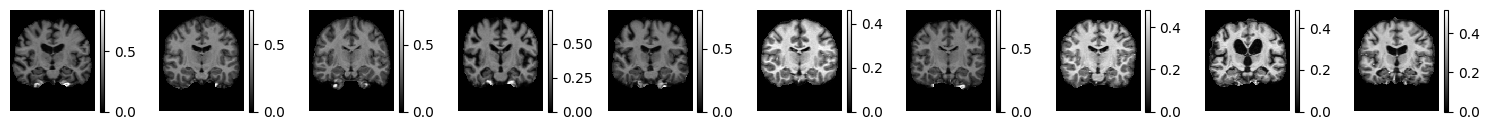

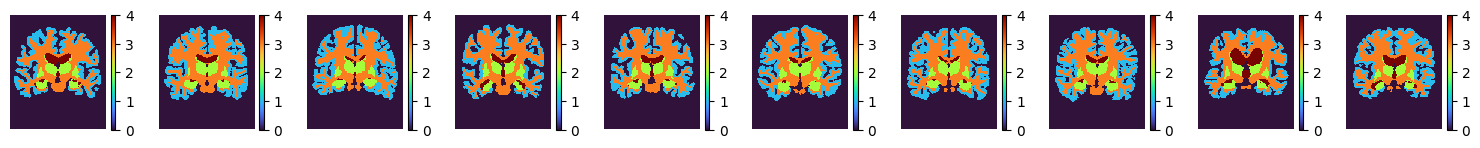

In [8]:
# grab two sets of samples from the training dataloader and visualize.
for i in range(0,2):
    sample = next(iter(dataloader_oasis_train))
    images = sample['image']
    segmentations = sample['segmentation']
    # undo one-hot encoding
    segmentations = torch.argmax(segmentations, dim=2, keepdim=True)
    # plot images
    slices = [f for f in images[0, :, 0, ...].cpu().detach().numpy()]
    ne.py.plot.slices(slices,do_colorbars=True)
    # plot segmentations
    slices_seg = [f for f in segmentations[0, :, 0, ...].cpu().detach().numpy()]
    ne.py.plot.slices(slices_seg,do_colorbars=True, cmaps=['turbo']*len(slices_seg))

## Setup the Model and Losses

In [7]:
import models as models
import layers as layers
import losses as losses
import torch.optim as optim


<frozen importlib._bootstrap_external>:1325: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


#### get the image size to set up the Spatial Transformer

In [8]:
oasis_img_size = list(map(int, list(oasis_data.shape[1:])))
print(oasis_img_size)

[192, 160]


### setup the loss functions

In [9]:
img_size = torch.Size(oasis_img_size)

# image and regularization loss
criterion = losses.local_NCC_2d(volshape=img_size, lbd=1)
#criterion = losses.MinVarAndGrad2d(volshape=img_size, lbd=0.1)
 
# segmentation loss
seg_loss = losses.DiceWarpLoss2d(img_size)
lambda_seg = 0.5

mmnet = models.GroupNet(in_channels=1, out_channels=2, img_size=img_size, do_diffeomorphism=True).to(device)

optimizer = optim.Adam(mmnet.parameters(), lr=0.001)


/usagers2/mumara/miniconda3/envs/shape_analysis/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Train

In [12]:
nb_epochs = 100
batch_size = 1
data_loader = dataloader_oasis_train
mmnet = mmnet.to(device)

pbar = trange(nb_epochs)
loss_hist = np.zeros(nb_epochs)

for i in pbar:
    total_running_loss = list()
    mmnet.train()
    for sample in data_loader:
        images = sample['image'].to(device)
        segmentations = sample['segmentation'].to(device)

        # zero the parameter gradients
        optimizer.zero_grad()
        # predict the warp fields
        predw = mmnet(images)
        # compute the loss
        loss = criterion(images, predw)
        loss_seg = seg_loss(segmentations,predw)
        loss = loss + lambda_seg * loss_seg
        total_running_loss.append(loss.item())
        #optimize
        loss.backward()
        optimizer.step()

    # print stats
    m = np.mean(total_running_loss)
    pbar.set_description(f'{m:.5f}')
    loss_hist[i] = m

print('Finished Training')

  0%|          | 0/100 [00:00<?, ?it/s]

Finished Training


Don't forget to save your model. Especially if you use colab. Otherwise it'll be deleted after you close your browser.

In [10]:
# save your model

import os

print("state dict")
state_dict = mmnet.state_dict()

models_path = "atlas_models"
best_model_path = "best_atlas.pth"

if os.path.exists(models_path):
    print("path ex")

if not os.path.exists(models_path):
    os.makedirs(models_path)
    print("path not exist")

# Saved inside multimorph/src/models
torch.save(state_dict, os.path.join(models_path, best_model_path))

state dict
path ex


### Test data?

In [ ]:
# # load the model (previously saved)
# models_path = "atlas_models"
# best_model_path = "best_atlas.pth"

# full_model_path = os.path.join(models_path, best_model_path)


# model = mmnet()

# state_dict = torch.load(best_model_path, map_location="cpu")
# model.load_state_dict(state_dict)
# model.eval()


AttributeError: 'collections.OrderedDict' object has no attribute 'test'

#### Visualize the training loss

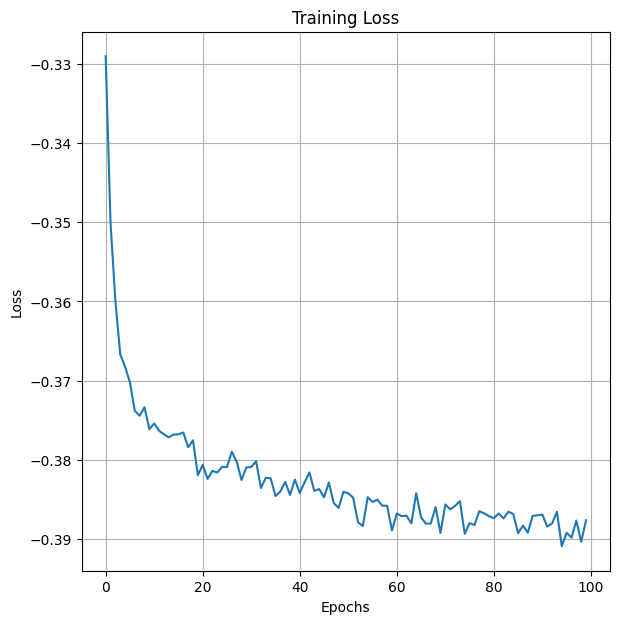

In [15]:
# lets quickly see the training curve
plt.figure(figsize=(15, 7))
plt.subplot(1,2,1)
plt.plot(loss_hist)
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.title('Training Loss')
plt.grid()


## Visualize the warps and atlas on samples from the train set

### setup a few plotting and warping functions

In [10]:
from utils import warp_seg, warp_image, warp_grid, setup_grid_tensor, plot_row_slices

### load a sample and plot the images and segmentations after warping

N images 2
Original Images


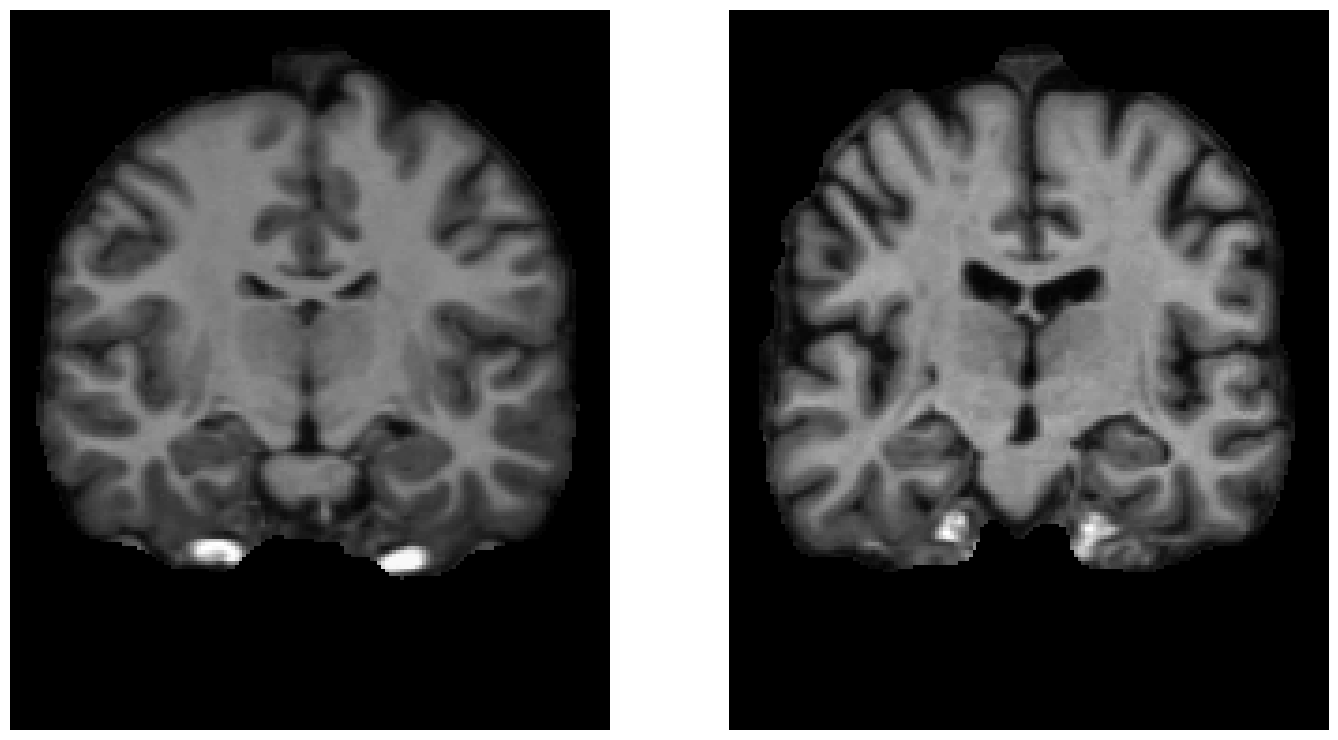

Warped Images


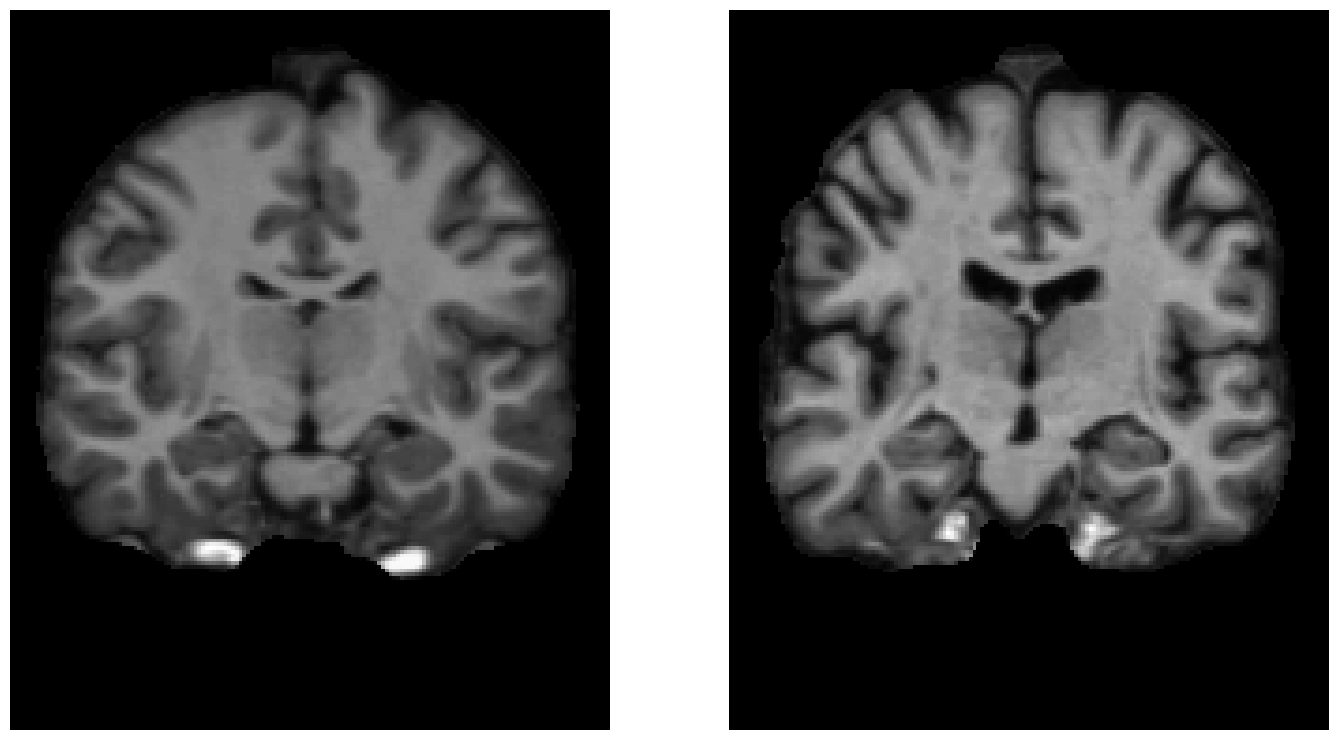

Original Segmentations


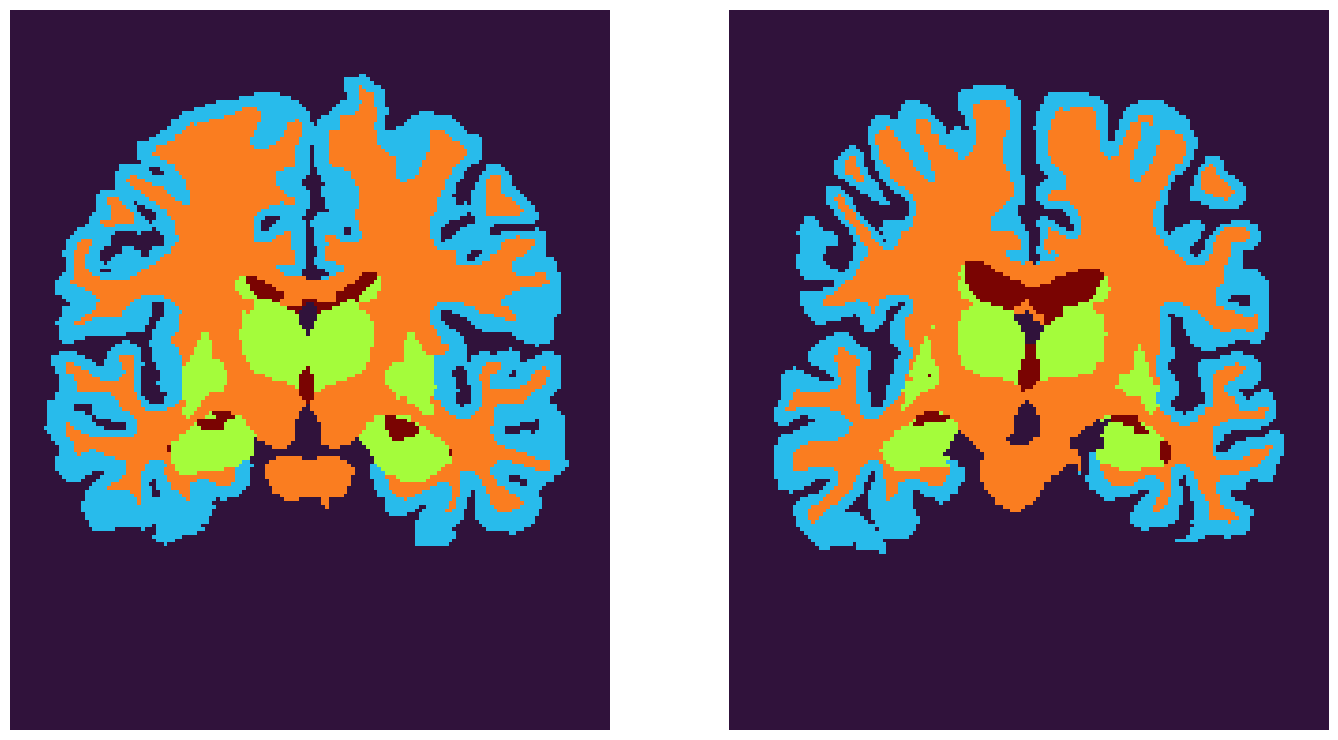

Warped Segmentations


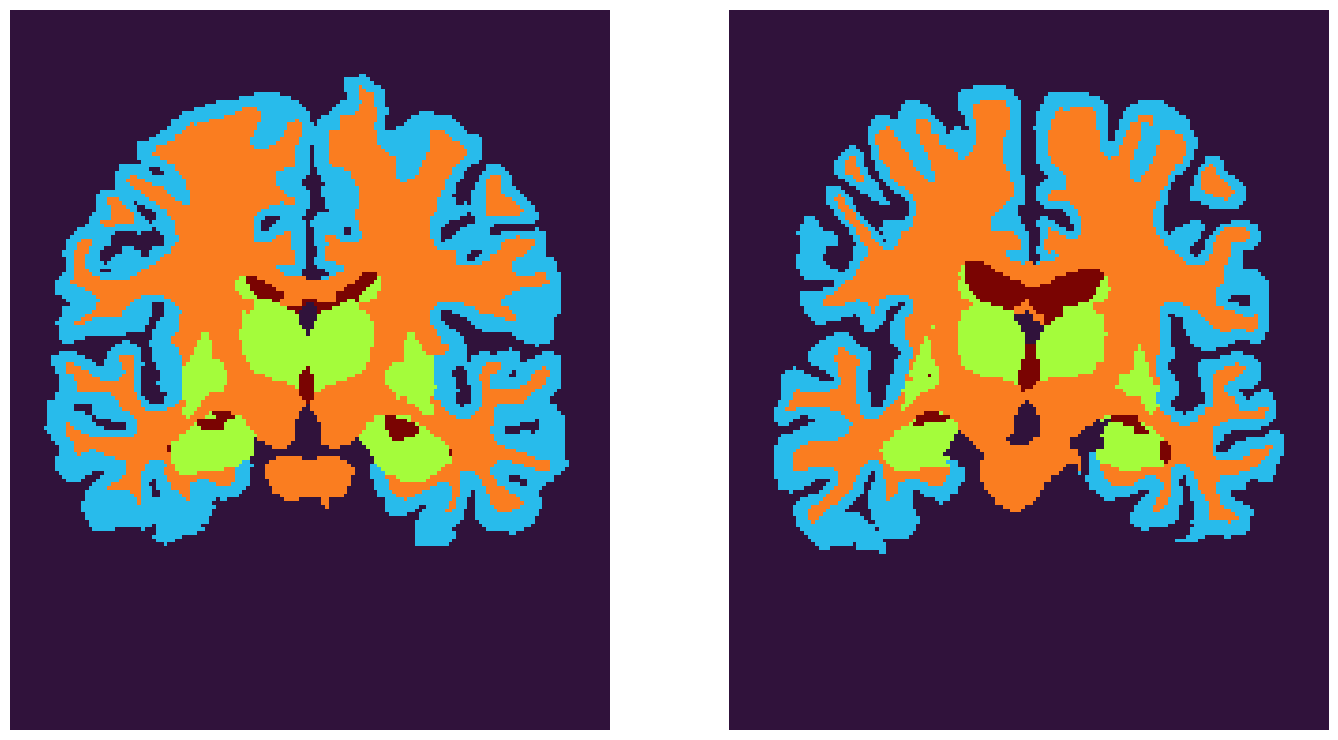

Warped Grid


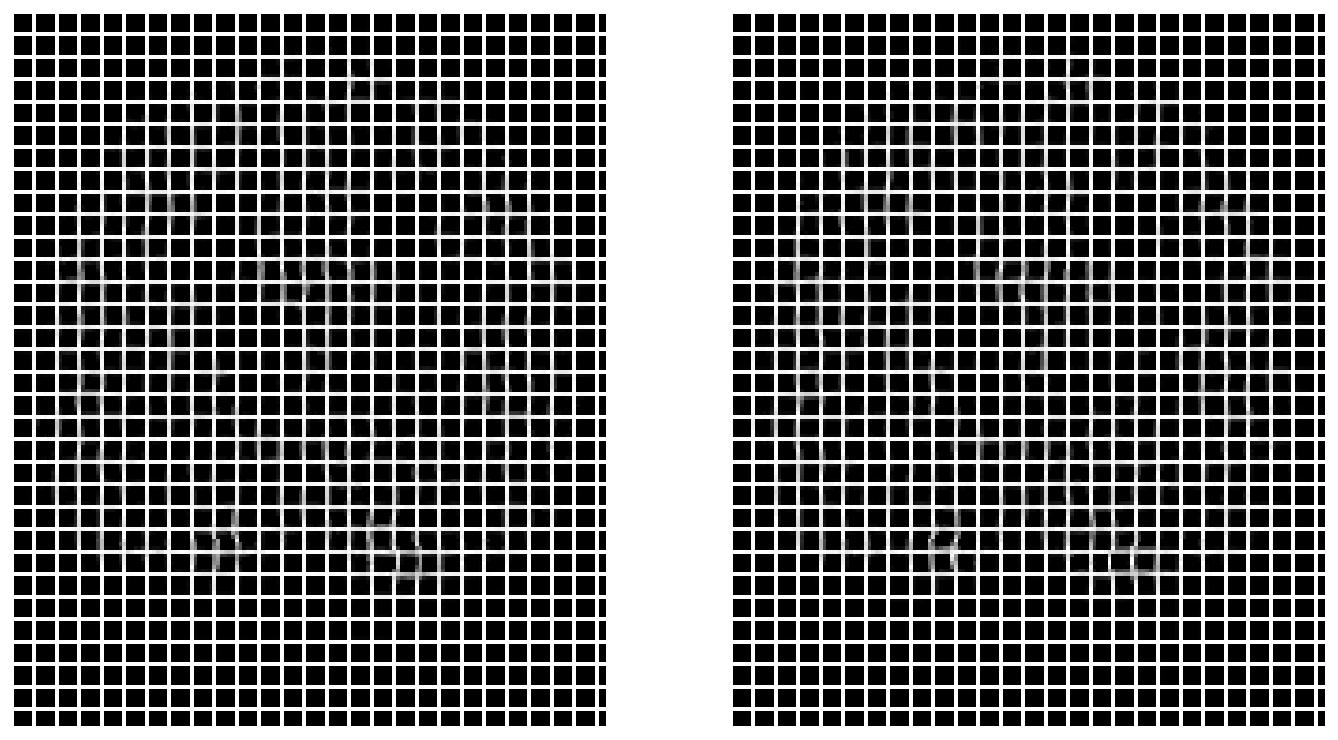

(<Figure size 1500x750 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

In [11]:
img_size = oasis_img_size
dataset = dataset_oasis_train
warp_dim = img_size

# set up the train data loader
mmnet.to(device)
gen =  iter(DataLoader(dataset,batch_size=1,shuffle=False))

# grab a sample from the data loader
sample = next(gen)
images = sample['image'].to(device)
segs = sample['segmentation'].to(device)
N_images = np.shape(images)[1]

print(f"N images {N_images}")

# warp and plot original, warped images
warped, predicted_warp = warp_image(images,mmnet,img_size)
warped_seg = warp_seg(segs, predicted_warp, img_size=img_size)

# plot the original and warped images
print('Original Images')
plot_row_slices(images, do_colorbars=False)
print('Warped Images')
plot_row_slices(warped, do_colorbars=False)

# plot the original and warped segmentations
print('Original Segmentations')
plot_row_slices(torch.round(torch.argmax(segs, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)
print('Warped Segmentations')
plot_row_slices(torch.round(torch.argmax(warped_seg, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)

# Create a grid and plot the warped grid
grids = setup_grid_tensor(N_slices=N_images,spacing=5, img_size=img_size).to(device)
warped_grid = warp_grid(grids, predicted_warp, warp_dim=img_size)
print('Warped Grid')
plot_row_slices(warped_grid, do_colorbars=False)

In [ ]:
img_size = oasis_img_size
dataset = dataset_oasis_train
warp_dim = img_size

# set up the train data loader
mmnet.to(device)
gen =  iter(DataLoader(dataset,batch_size=1,shuffle=False))

# grab a sample from the data loader
sample = next(gen)
images = sample['image'].to(device)
segs = sample['segmentation'].to(device)
N_images = np.shape(images)[1]

# warp and plot original, warped images
warped, predicted_warp = warp_image(images,mmnet,img_size)
warped_seg = warp_seg(segs, predicted_warp, img_size=img_size)

# plot the original and warped images
print('Original Images')
plot_row_slices(images, do_colorbars=False)
print('Warped Images')
plot_row_slices(warped, do_colorbars=False)

# plot the original and warped segmentations
print('Original Segmentations')
plot_row_slices(torch.round(torch.argmax(segs, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)
print('Warped Segmentations')
plot_row_slices(torch.round(torch.argmax(warped_seg, dim=2, keepdim=True)), do_colorbars=False, cmaps=['turbo']*N_images)

# Create a grid and plot the warped grid
grids = setup_grid_tensor(N_slices=N_images,spacing=5, img_size=img_size).to(device)
warped_grid = warp_grid(grids, predicted_warp, warp_dim=img_size)
print('Warped Grid')
plot_row_slices(warped_grid, do_colorbars=False)

### visualize the resultant atlases, and compare to constructing an atlas by taking the mean

In [12]:
models_path = "atlas_models"
best_model_path = "best_atlas.pth"

mmnet.load_state_dict(torch.load(os.path.join(models_path, best_model_path)))
mmnet.to(device)
mmnet.eval()

GroupNet(
  (ups): ModuleList(
    (0): UpsamplingBilinear2d(
      (upsample): UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
    )
    (1): MeanConv2d(
      (conv): Sequential(
        (0): Conv2d(256, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
      )
    )
    (2): UpsamplingBilinear2d(
      (upsample): UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
    )
    (3): MeanConv2d(
      (conv): Sequential(
        (0): Conv2d(256, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
      )
    )
    (4): UpsamplingBilinear2d(
      (upsample): UpsamplingBilinear2d(scale_factor=2.0, mode='bilinear')
    )
    (5): MeanConv2d(
      (conv): Sequential(
        (0): Conv2d(256, 64, kernel_size=(3, 3)

### Comparison to mean construction

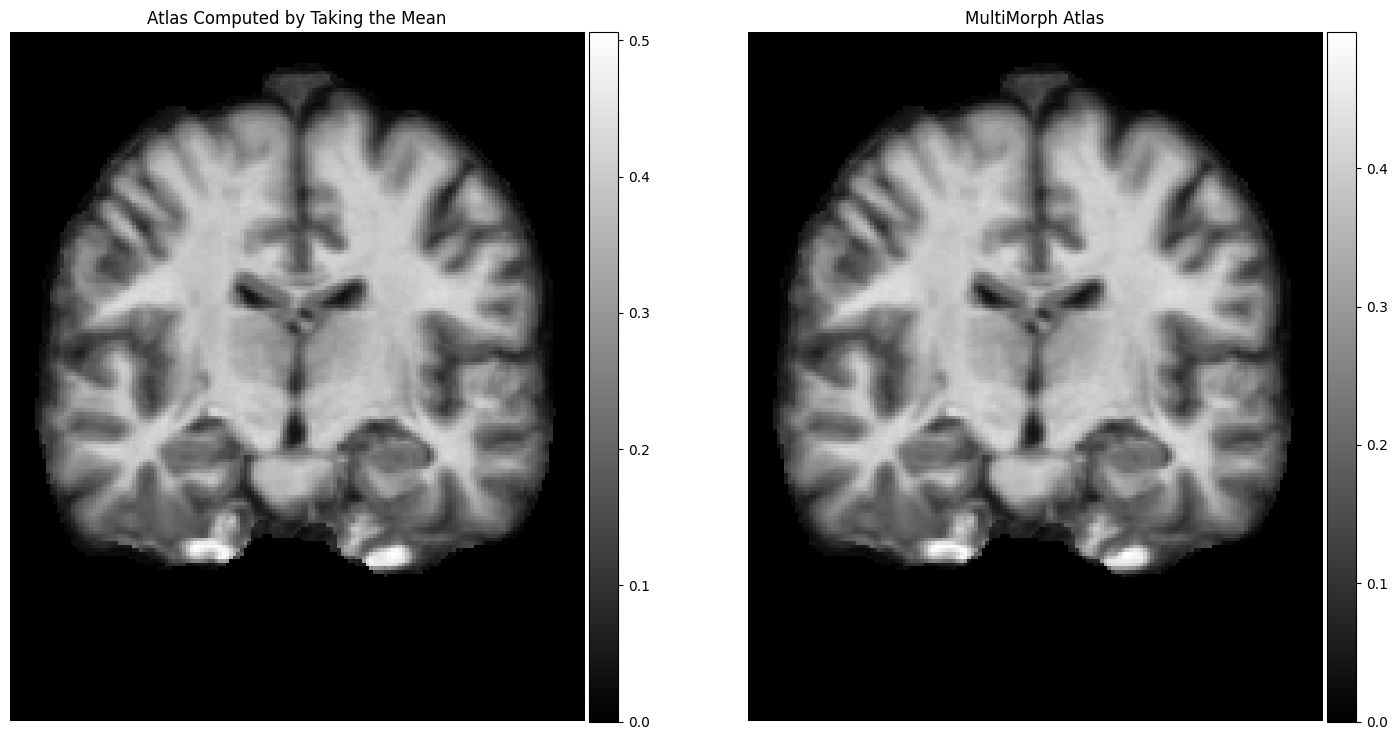

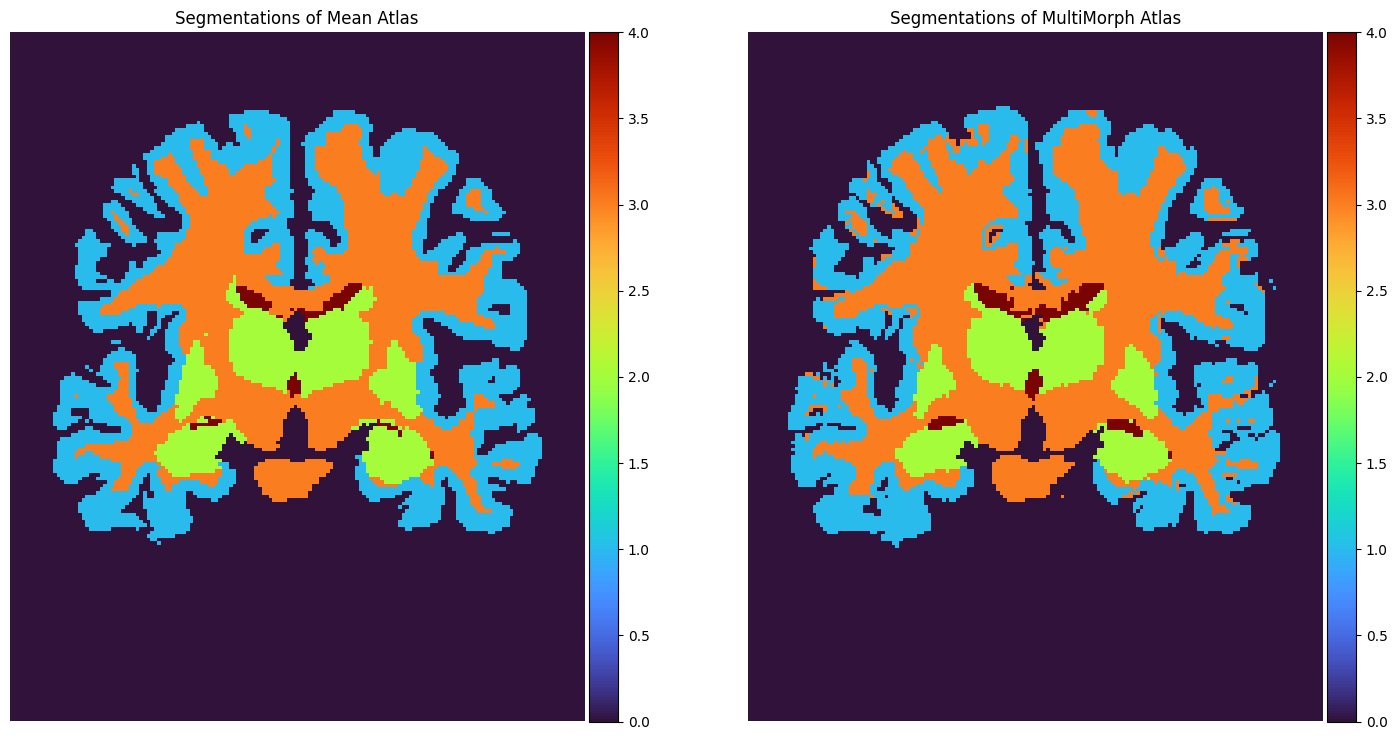

(<Figure size 1500x750 with 4 Axes>,
 array([<Axes: title={'center': 'Segmentations of Mean Atlas'}>,
        <Axes: title={'center': 'Segmentations of MultiMorph Atlas'}>],
       dtype=object))

In [ ]:
atl = torch.mean(images, dim=1, keepdims=True)
atlw = torch.mean(warped, dim=1, keepdims=True)
slices = [f.cpu().detach().numpy() for f in [atl, atlw]]
titles = ['Atlas Computed by Taking the Mean', 'MultiMorph Atlas']
ne.plot.slices(slices, do_colorbars=True, titles=titles)

mean_seg = torch.round(torch.argmax(torch.mean(segs,dim=1,keepdim=True), dim=2, keepdims=True))
mean_warped_seg = torch.round(torch.argmax(torch.mean(warped_seg, dim=1, keepdims=True), dim=2, keepdim=True))
slices = [f.cpu().detach().numpy() for f in [mean_seg, mean_warped_seg]]
titles = ['Segmentations of Mean Atlas', 'Segmentations of MultiMorph Atlas']
ne.plot.slices(slices, do_colorbars=True, titles=titles, cmaps=['turbo']*len(slices))

## Construct an Atlas on the Entire Test Set

In [14]:
import time

mmnet = mmnet.to('cpu')
mmnet.eval()
warp_layer = layers.group.Warp2d(img_size)
for sample in dataloader_oasis_test:
    st = time.time()
    images = sample['image'].to('cpu')
    segmentations = sample['segmentation'].to('cpu')
    # predict the warp fields
    predw = mmnet(images)
    # warp and plot original, warped images
    warped = warp_layer(images, predw)
    #warped_seg = warp_layer(segmentations, predw)
    #warped_seg = warp_seg(segmentations, predicted_warp, img_size=img_size)

# construct the atlases
atlas = torch.mean(warped, dim=1, keepdims=True)
atlas_segmentation = torch.round(torch.argmax(torch.mean(warped_seg, dim=1, keepdims=True), dim=2, keepdim=True))

et = time.time()
print(f'Atlas Construction took {et-st:.3f} seconds for {images.shape[1]} images')


Atlas Construction took 3.170 seconds for 42 images


#### plot the constructed atlases

Text(0.5, 1.0, 'Segmentations of MultiMorph Atlas')

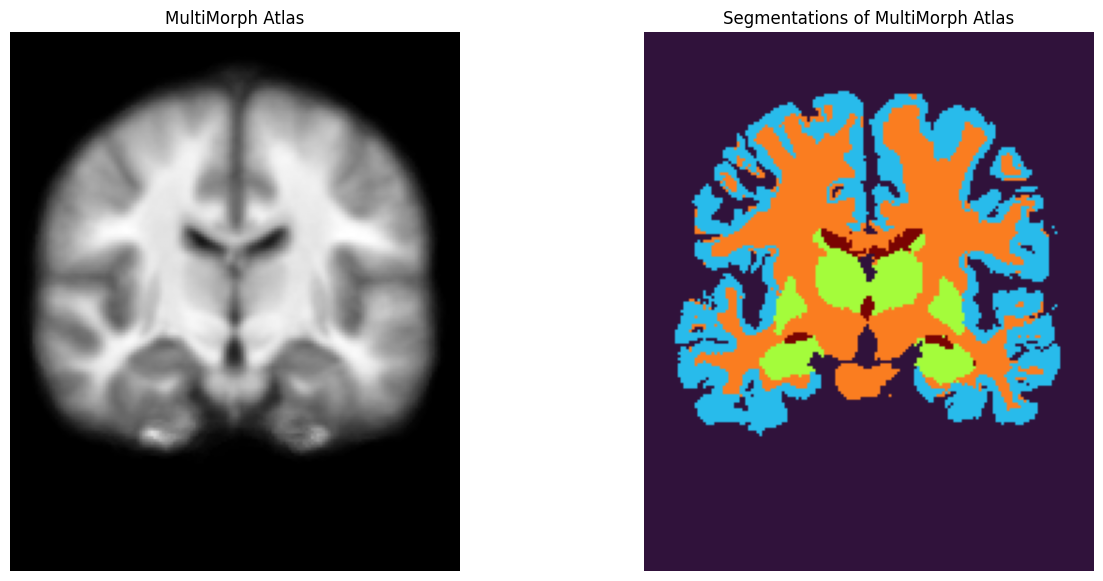

In [15]:

plt.figure(figsize=(15, 7))
plt.subplot(1,2,1)
plt.imshow(atlas[0, 0, 0, ...].cpu().detach().numpy(), cmap='gray')
plt.axis('off')
plt.title('MultiMorph Atlas')
plt.subplot(1,2,2)
plt.imshow(atlas_segmentation[0, 0, 0, ...].cpu().detach().numpy(), cmap='turbo')
plt.axis('off')
plt.title('Segmentations of MultiMorph Atlas')


### save the atlases (don't forget to download them if you use google colab)

In [16]:
atlas_path = 'oasis_atlas_2d.nii.gz'
atlas_segmentation_path = 'oasis_atlas_segmentation_2d.nii.gz'
nib.save(nib.Nifti1Image(atlas[0, 0, 0, ...].cpu().detach().numpy(), np.eye(4)), atlas_path)
nib.save(nib.Nifti1Image(atlas_segmentation[0, 0, 0, ...].float().cpu().detach().numpy(), np.eye(4)), atlas_segmentation_path)


# Statistical Shape analysis

Related to course 6 : Statistical Shape Analysis.

Present other statistical shape analyses that you consider relevant. Please include plots of your results.

You can use velocity fields (available in the code : https://github.com/mabulnaga/multimorph/blob/main/src/models.py) and compute PCA, Standard deviation, etc. Feel free to go wild!

In [ ]:
# TODO

In [ ]:
# ============================================================================
# PRINCIPAL GEODESIC ANALYSIS (PGA) POUR ATLAS CONSTRUCTION
# ============================================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.linalg import svd

# ============================================================================
# 1. FONCTIONS GÉODÉSIQUES DE BASE
# ============================================================================

def geodesic_distance(x, y):
    """
    Calcule la distance géodésique entre deux vecteurs sur la sphère
    """
    dot_product = np.sum(x * y)
    mag_x = np.linalg.norm(x)
    mag_y = np.linalg.norm(y)
    
    if mag_x == 0 or mag_y == 0:
        return 0
    
    cosine = dot_product / (mag_x * mag_y)
    cosine = np.clip(cosine, -1.0, 1.0)  # Clamp pour éviter erreurs numériques
    
    return np.arccos(cosine)

def log_map(x, y):
    """
    Logarithmic map: projette y sur l'espace tangent en x
    """
    d = geodesic_distance(x, y)
    temp = y - np.sum(x * y) * x
    
    if np.linalg.norm(temp) > 1e-10:
        mapped_value = d * (temp / np.linalg.norm(temp))
    else:
        mapped_value = np.zeros_like(x)
    
    return mapped_value

def exp_map(p, v):
    """
    Exponential map: projette un vecteur tangent v en p vers la variété
    """
    mag_v = np.linalg.norm(v)
    
    if mag_v < 1e-10:
        return p
    
    v_normalized = v / mag_v
    mapped_value = p * np.cos(mag_v) + v_normalized * np.sin(mag_v)
    
    return mapped_value

def parallel_transport(v, p, q):
    """
    Transport parallèle d'un vecteur v de p vers q
    """
    logmap1 = log_map(p, q)
    logmap2 = log_map(q, p)
    
    norm1 = np.linalg.norm(logmap1)
    norm2 = np.linalg.norm(logmap2)
    
    if norm1 > 1e-10 and norm2 > 1e-10:
        d = geodesic_distance(p, q)
        if d > 1e-10:
            transported_value = v - (np.dot(logmap1, v) / d) * (logmap1 + logmap2)
        else:
            transported_value = v
    else:
        transported_value = v
    
    return transported_value

# ============================================================================
# 2. CALCUL DE LA MOYENNE GÉODÉSIQUE (FRÉCHET MEAN)
# ============================================================================

def calculate_geodesic_mean(data, max_iter=100, lr=0.01, tol=1e-6):
    """
    Calcule la moyenne géodésique (Fréchet mean) des données
    
    Args:
        data: array [N, dim] où N = nombre d'échantillons
        max_iter: nombre maximum d'itérations
        lr: learning rate
        tol: tolérance pour la convergence
    
    Returns:
        mean: vecteur moyen sur la variété
    """
    N, dim = data.shape
    
    # Initialisation: moyenne euclidienne normalisée
    mean = np.mean(data, axis=0)
    mean = mean / (np.linalg.norm(mean) + 1e-10)
    
    print("Calcul de la moyenne géodésique...")
    
    for i in range(max_iter):
        grad = np.zeros(dim)
        
        # Gradient = somme des log maps
        for j in range(N):
            grad -= log_map(mean, data[j])
        
        grad = grad / N
        
        # Mise à jour via exponential map
        mean_new = exp_map(mean, -lr * grad)
        
        # Convergence check
        change = np.linalg.norm(mean_new - mean)
        mean = mean_new
        
        if (i + 1) % 20 == 0:
            print(f"  Iter {i+1}/{max_iter}, change: {change:.6f}")
        
        if change < tol:
            print(f"  Convergé à l'itération {i+1}")
            break
    
    return mean


### PGA implementation

In [ ]:
def principal_geodesic_analysis(data, n_components=None):
    """
    Effectue une PGA sur les données
    
    Args:
        data: array [N, dim] - N échantillons de dimension dim
        n_components: nombre de composantes principales (None = toutes)
    
    Returns:
        mean: moyenne géodésique
        principal_vectors: vecteurs principaux
        magnitudes: valeurs singulières (variance)
        mapped_points: données projetées dans l'espace tangent
    """
    N, dim = data.shape
    
    mean = calculate_geodesic_mean(data)
    
    print("\nProjection dans l'espace tangent...")
    mapped_points = np.array([log_map(mean, data[i]) for i in range(N)])
    
    # 3. PCA dans l'espace tangent
    print("SVD dans l'espace tangent...")
    U, S, Vt = svd(mapped_points.T, full_matrices=False)
    
    principal_vectors = U
    magnitudes = S
    
    # Variance expliquée
    total_var = np.sum(magnitudes ** 2)
    explained_var = (magnitudes ** 2) / total_var * 100
    
    if n_components is not None:
        principal_vectors = principal_vectors[:, :n_components]
        magnitudes = magnitudes[:n_components]
        explained_var = explained_var[:n_components]
    
    print(f"\n{'Composante':<15} {'Magnitude':<15} {'Variance %':<15}")
    print("-" * 45)
    for i in range(min(5, len(magnitudes))):
        print(f"PC{i+1:<14} {magnitudes[i]:<15.4f} {explained_var[i]:<15.2f}")
    
    return {
        'mean': mean,
        'principal_vectors': principal_vectors,
        'magnitudes': magnitudes,
        'explained_variance': explained_var,
        'mapped_points': mapped_points
    }

# ============================================================================
# 4. APPLICATION AUX WARPS (CHAMPS DE DÉFORMATION)
# ============================================================================

def flatten_warp_field(warp_field):
    """
    Flatten un champ de déformation pour PGA
    
    Args:
        warp_field: tensor [H, W, 2] ou [B, H, W, 2]
    
    Returns:
        flattened: array [dim] où dim = H*W*2
    """
    if isinstance(warp_field, torch.Tensor):
        warp_field = warp_field.cpu().numpy()
    
    if warp_field.ndim == 4:  # [B, H, W, 2]
        warp_field = warp_field[0]
    
    return warp_field.reshape(-1)


def unflatten_warp_field(flat_warp, img_size):
    """
    Reconstruit un champ de déformation depuis sa version flattened
    
    Args:
        flat_warp: array [H*W*2]
        img_size: tuple (H, W) ou int
    
    Returns:
        warp_field: array [H, W, 2]
    """
    # Gérer les cas où img_size est un tuple ou un int
    if isinstance(img_size, (list, tuple)):
        H, W = img_size
    else:
        H = W = img_size
    
    return flat_warp.reshape(H, W, 2)

# ============================================================================
# 5. ANALYSE PGA SUR VOS DONNÉES
# ============================================================================

print("\n" + "="*70)
print("PRINCIPAL GEODESIC ANALYSIS SUR LES CHAMPS DE DÉFORMATION")
print("="*70)

# Collecter les champs de déformation de tous les échantillons
print("\nCollection des champs de déformation...")
all_warps_flat = []

gen = iter(DataLoader(dataset_oasis_train, batch_size=1, shuffle=False))
with torch.no_grad():
    for idx, sample in enumerate(gen):
        images = sample['image'].to(device)
        
        # Obtenir les warps prédits
        warped, predicted_warp = warp_image(images, mmnet, oasis_img_size)
        
        # Flatten chaque warp du batch
        for i in range(predicted_warp.shape[1]):  # Pour chaque image dans le sample
            warp_i = predicted_warp[0, i].cpu().numpy()  # [H, W, 2]
            warp_flat = warp_i.reshape(-1)
            
            # Normaliser (important pour géodésiques)
            warp_flat = warp_flat / (np.linalg.norm(warp_flat) + 1e-10)
            all_warps_flat.append(warp_flat)

all_warps_flat = np.array(all_warps_flat)  # [N_total_images, dim]
print(f"Shape des warps: {all_warps_flat.shape}")

# Effectuer PGA
pga_results = principal_geodesic_analysis(all_warps_flat, n_components=10)

# Extraire les résultats
mean_warp = pga_results['mean']
principal_vectors = pga_results['principal_vectors']
magnitudes = pga_results['magnitudes']
explained_var = pga_results['explained_variance']

print(f"\nVariance totale expliquée par 5 premières composantes: {np.sum(explained_var[:5]):.2f}%")



PRINCIPAL GEODESIC ANALYSIS SUR LES CHAMPS DE DÉFORMATION

Collection des champs de déformation...
Shape des warps: (2417, 61440)
Calcul de la moyenne géodésique...
  Iter 20/100, change: 0.000305
  Iter 40/100, change: 0.000307
  Iter 60/100, change: 0.000308
  Iter 80/100, change: 0.000310
  Iter 100/100, change: 0.000311

Projection dans l'espace tangent...
SVD dans l'espace tangent...

Composante      Magnitude       Variance %     
---------------------------------------------
PC1              19.1531         6.09           
PC2              13.9006         3.21           
PC3              13.0648         2.83           
PC4              12.0689         2.42           
PC5              10.9243         1.98           

Variance totale expliquée par 5 premières composantes: 16.52%


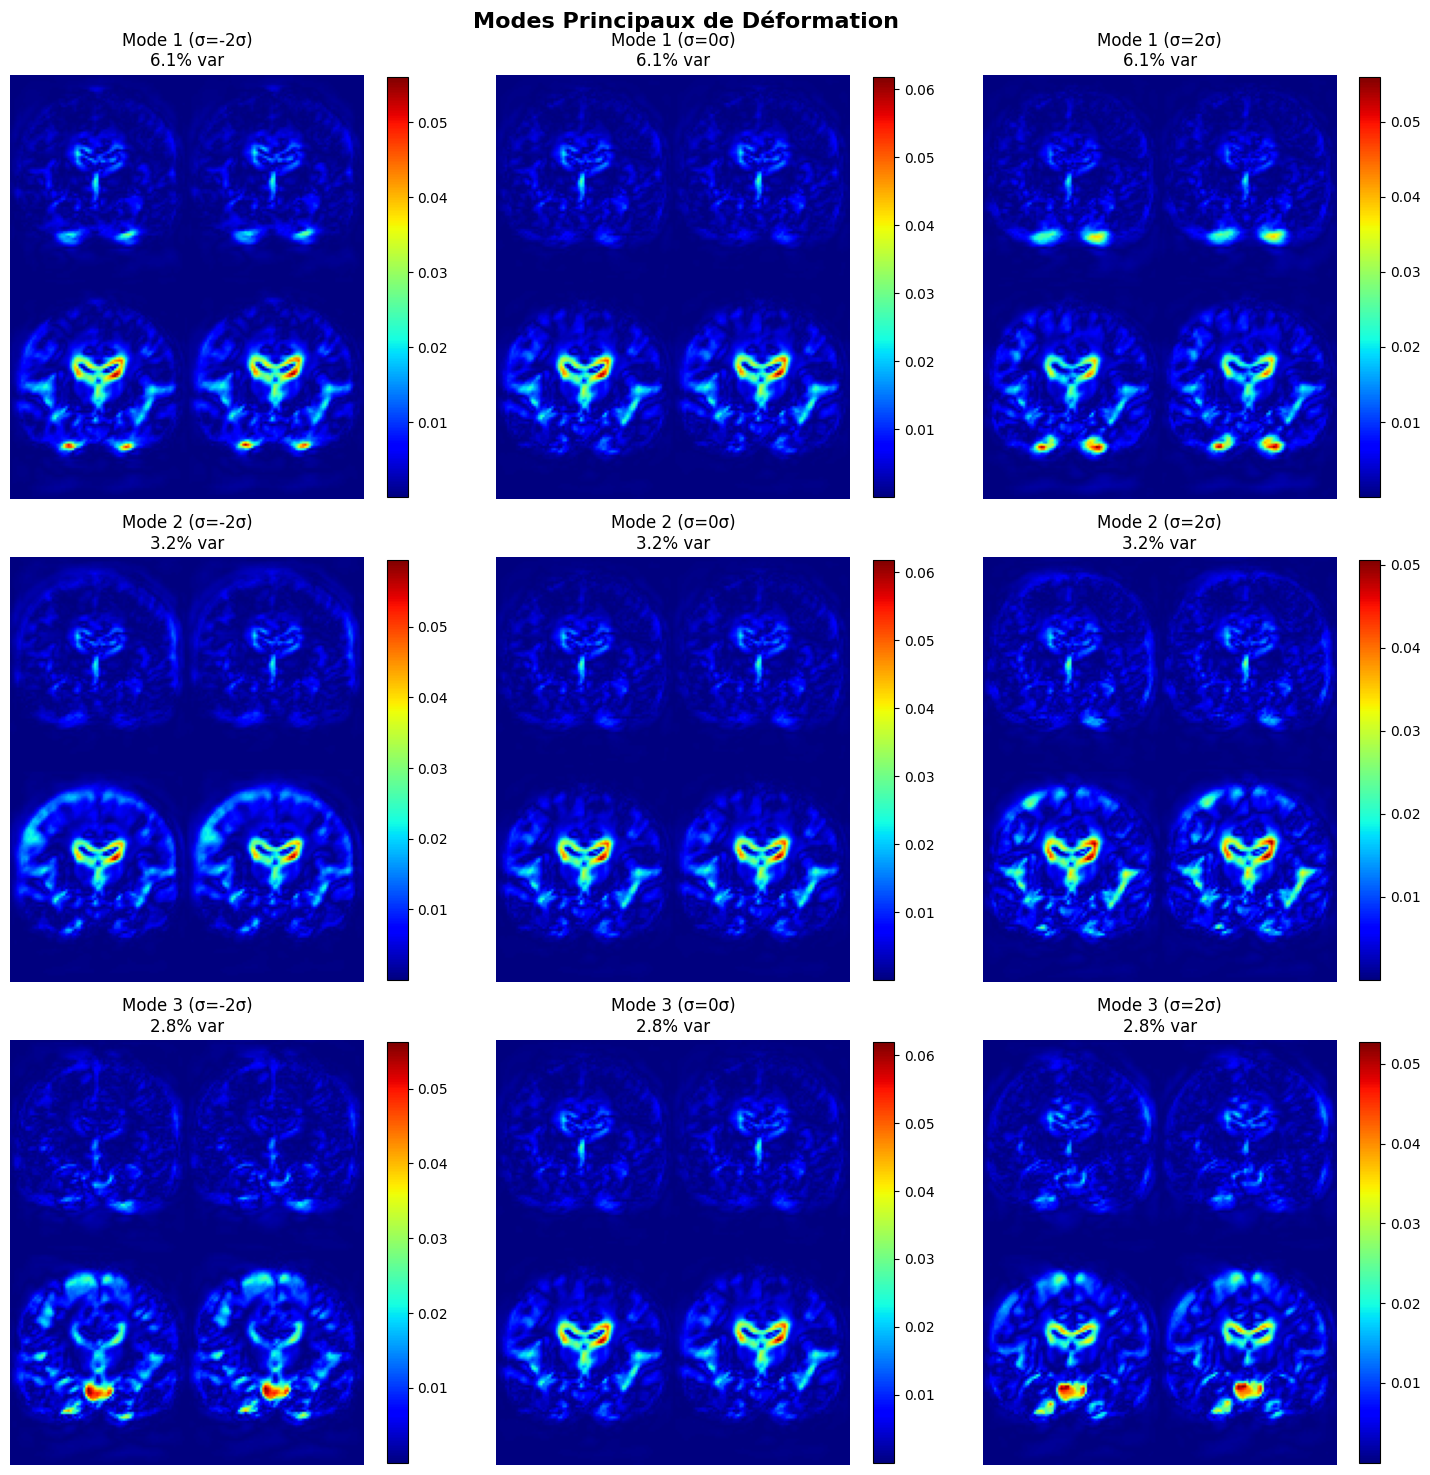


GÉNÉRATION DE NOUVELLES DÉFORMATIONS


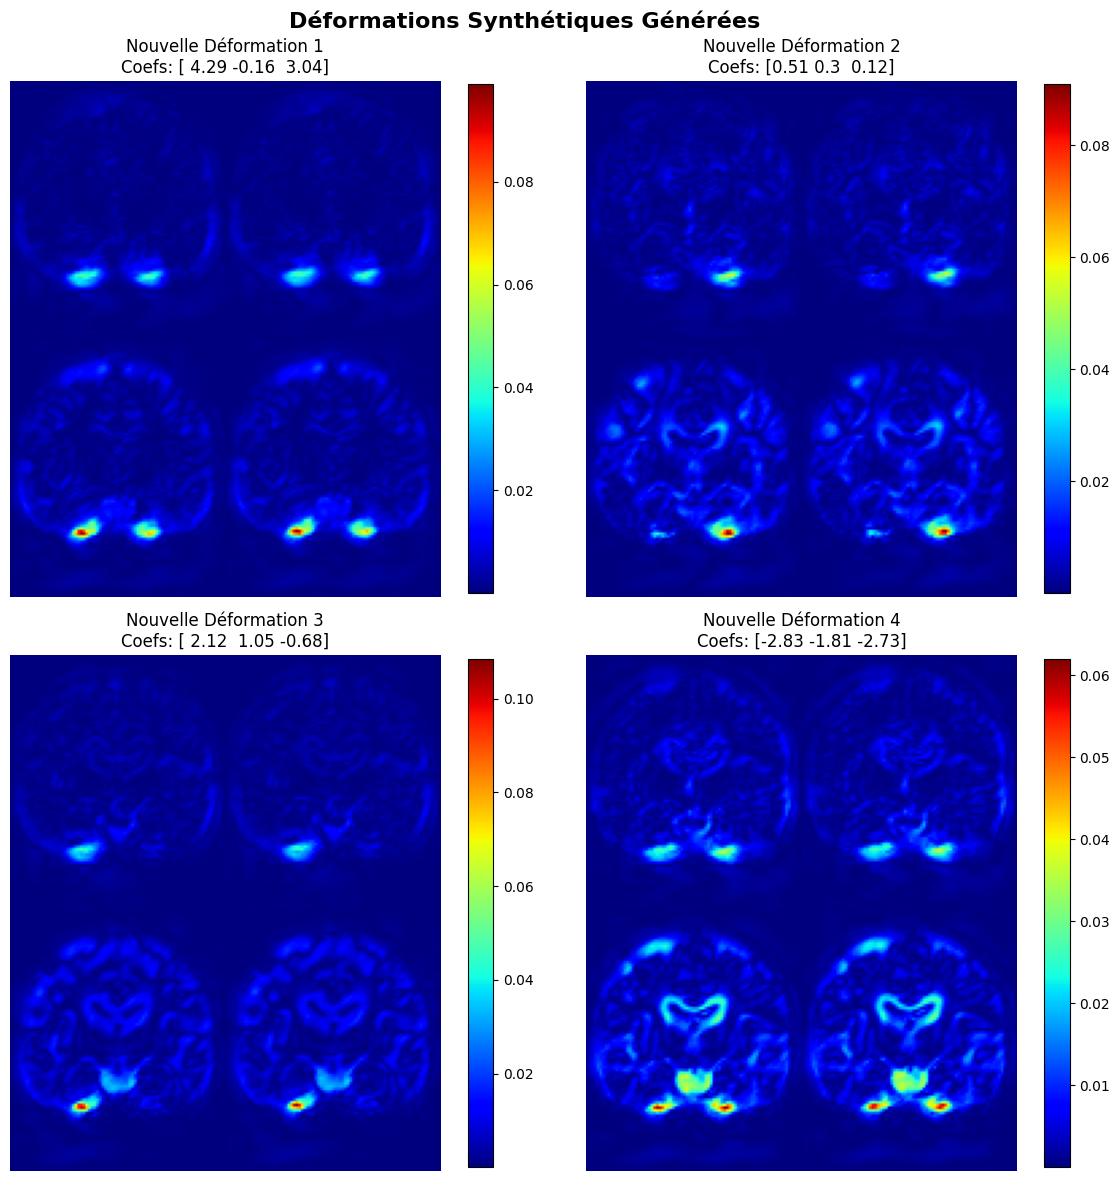

In [ ]:

# ============================================================================
# 6. VISUALISATION DES MODES PRINCIPAUX (CORRIGÉE)
# ============================================================================

def visualize_principal_modes(mean_warp, principal_vectors, magnitudes, 
                              img_size, n_modes=3, scale_factors=[-2, 0, 2]):
    """
    Visualise les modes principaux de variation
    """
    # Gérer img_size
    if isinstance(img_size, (list, tuple)):
        H, W = img_size
    else:
        H = W = img_size
    
    fig, axes = plt.subplots(n_modes, len(scale_factors), figsize=(15, 5*n_modes))
    
    for mode_idx in range(n_modes):
        for scale_idx, scale in enumerate(scale_factors):
            # Générer variation: mean + scale * magnitude * principal_vector
            variation = mean_warp + scale * magnitudes[mode_idx] * principal_vectors[:, mode_idx]
            
            # Projeter retour sur la variété
            variation = exp_map(mean_warp, variation - mean_warp)
            
            # Reconstruire le warp field
            warp_field = unflatten_warp_field(variation, (H, W))  # Passer tuple
            
            # Visualiser magnitude du warp
            warp_magnitude = np.sqrt(warp_field[:, :, 0]**2 + warp_field[:, :, 1]**2)
            
            ax = axes[mode_idx, scale_idx] if n_modes > 1 else axes[scale_idx]
            im = ax.imshow(warp_magnitude, cmap='jet')
            ax.set_title(f'Mode {mode_idx+1} (σ={scale}σ)\n{explained_var[mode_idx]:.1f}% var')
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046)
    
    plt.suptitle('Modes Principaux de Déformation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualiser les 3 premiers modes - CORRECTION ICI
visualize_principal_modes(mean_warp, principal_vectors, magnitudes, 
                         img_size=oasis_img_size, n_modes=3)  # Passer directement l'int


def generate_new_warp(mean_warp, principal_vectors, magnitudes, 
                      coefficients, img_size):
    """
    Génère un nouveau champ de déformation à partir des coefficients PGA
    
    Args:
        mean_warp: moyenne géodésique
        principal_vectors: vecteurs principaux
        magnitudes: valeurs singulières
        coefficients: array [n_components] - coefficients pour chaque mode
        img_size: int ou tuple (H, W)
    
    Returns:
        warp_field: nouveau champ de déformation [H, W, 2]
    """
    # Gérer img_size
    if isinstance(img_size, (list, tuple)):
        H, W = img_size
    else:
        H = W = img_size
    
    # Combinaison linéaire dans l'espace tangent
    tangent_vector = np.zeros_like(mean_warp)
    for i, coef in enumerate(coefficients):
        tangent_vector += coef * magnitudes[i] * principal_vectors[:, i]
    
    # Projeter sur la variété
    new_warp = exp_map(mean_warp, tangent_vector)
    
    # Reconstruire
    warp_field = unflatten_warp_field(new_warp, (H, W))  # Passer tuple
    
    return warp_field

# Exemple: générer 4 nouvelles déformations aléatoires
print("\n" + "="*70)
print("GÉNÉRATION DE NOUVELLES DÉFORMATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i in range(4):
    # Coefficients aléatoires (distribution normale)
    coefficients = np.random.randn(5) * 2  # 5 premières composantes
    
    # Générer warp - CORRECTION ICI
    new_warp = generate_new_warp(mean_warp, principal_vectors, magnitudes, 
                                  coefficients, img_size=oasis_img_size)  # Passer int
    
    # Visualiser
    warp_mag = np.sqrt(new_warp[:, :, 0]**2 + new_warp[:, :, 1]**2)
    im = axes[i].imshow(warp_mag, cmap='jet')
    axes[i].set_title(f'Nouvelle Déformation {i+1}\nCoefs: {coefficients[:3].round(2)}')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Déformations Synthétiques Générées', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [18]:
# ============================================================================
# 9. PROJECTION D'UN NOUVEAU WARP SUR LE MODÈLE
# ============================================================================

def project_warp_to_pga(warp_field, mean_warp, principal_vectors, img_size):
    """
    Projette un nouveau warp sur le modèle PGA
    
    Returns:
        coefficients: coefficients dans l'espace PGA
        reconstructed_warp: reconstruction depuis PGA
    """
    # Gérer img_size
    if isinstance(img_size, (list, tuple)):
        H, W = img_size
    else:
        H = W = img_size
    
    # Flatten et normaliser
    warp_flat = warp_field.reshape(-1)
    warp_flat = warp_flat / (np.linalg.norm(warp_flat) + 1e-10)
    
    # Projeter dans espace tangent
    tangent_vector = log_map(mean_warp, warp_flat)
    
    # Coefficients = projection sur vecteurs principaux
    coefficients = tangent_vector @ principal_vectors
    
    # Reconstruction
    reconstructed_tangent = principal_vectors @ coefficients
    reconstructed_flat = exp_map(mean_warp, reconstructed_tangent)
    reconstructed_warp = unflatten_warp_field(reconstructed_flat, (H, W))  # Passer tuple
    
    return coefficients, reconstructed_warp

print("\n✅ PGA terminée! Modèle prêt pour génération et analyse.")


✅ PGA terminée! Modèle prêt pour génération et analyse.
